# Clustering 

The **objective** of clustering is to group the observations of (n) individuals based on their values across multiple variables.

Remember:

- A variable is a measurable characteristic or property of the individuals.
An individual is one observation, described by the values of all the variables measured for it.

- For example, if we are studying weather conditions, an individual could be one day, while the variables could be temperature, precipitation, wind speed, and atmospheric pressure.

Clustering aims to identify groups of individuals that are similar to each other based on these variables. Although multiple clustering algorithms exist, they generally require us to answer two fundamental questions:

1. How do we measure **dissimilarity** between individuals?

2. How do we evaluate the **quality of a group** of individuals?

## 01. What does similar or dissimilar mean?

Lets import some libraries that we will need for the rest of the notebook

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

We are going to generate a random dataset consisting of 20 individuals, for which two variables have been measured.

The values of both variables are randomly sampled from a normal distribution with a mean of 0 and a standard deviation of 1.

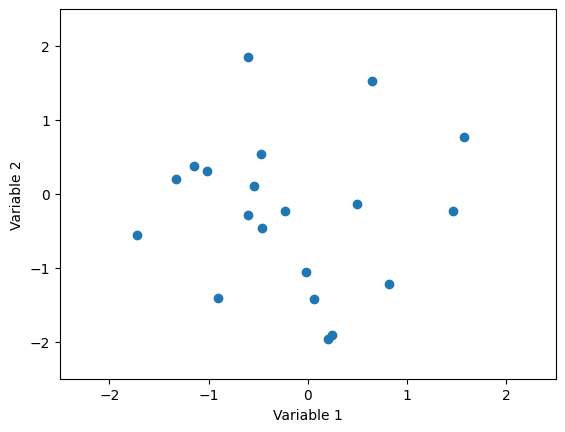

In [2]:
np.random.seed(42)

X = np.random.normal(
    loc=[0, 0],
    scale=[1, 1],
    size=(20, 2)
)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")

plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)

plt.show()

We can now ask a fundamental question: how similar are two individuals? One simple way to measure dissimilarity is to calculate the distance between them. We typically use the Euclidean distance between two individuals (i) and (j), considering (p) variables, is defined as:
$$
\sqrt{
\sum_{k=1}^{p}
\left(x_{ik}-x_{jk}\right)^2
}
]
$$
For our case, where we have two variables, this becomes:
$$
\sqrt{
(x_{i1}-x_{j1})^2
+
(x_{i2}-x_{j2})^2
}
]
$$
The Euclidean distance corresponds to the straight-line distance between two points.

A smaller distance means that two individuals are more similar, while a larger distance means that they are more dissimilar. 

Let's select one individual and calculate its distance to the other individuals.

In [3]:
individual_s = X[0]
print('Individual sample:', individual_s)

distances = np.sqrt(
    (X[:, 0] - individual_s[0])**2 +
    (X[:, 1] - individual_s[1])**2
) 

Individual sample: [ 0.49671415 -0.1382643 ]


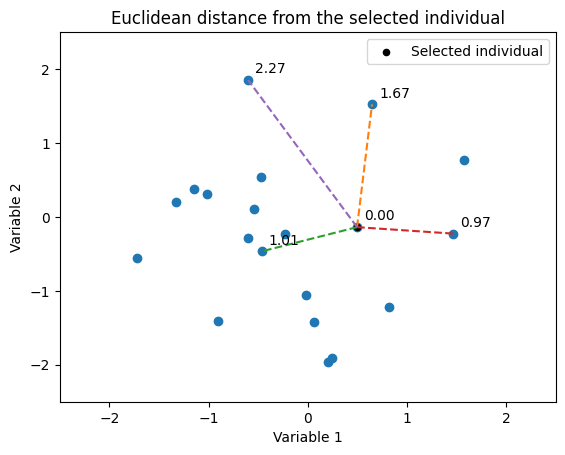

In [4]:
fig, ax = plt.subplots()

ax.scatter(X[:, 0], X[:, 1])
# Highlight the selected individual
ax.scatter(
    X[0, 0],
    X[0, 1],
    s=20,
    label="Selected individual",
    color='k'
)

# Show distances to a few individuals
for i in [0, 1, 5, 10, 15]:
    ax.plot(
        [X[0, 0], X[i, 0]],
        [X[0, 1], X[i, 1]],
        linestyle="--"
    )
    
    ax.annotate(
        f"{distances[i]:.2f}",
        (X[i, 0], X[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_title("Euclidean distance from the selected individual")
ax.legend()

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)

plt.show()

The Euclidean distance works well and is intuitive when variables have similar scales. However, if variables are measured on very different scales, the distance can be dominated by the variable with the largest scale.

In this case, we can standardize the variables before calculating distances, or use a distance metric that accounts for the scale and correlation between variables, such as the Mahalanobis distance.

However, the choice of scaling is ultimately a modelling decision. If we consider one variable to be more important than another, we can deliberately give it a larger weight in the distance calculation.

This becomes particularly relevant when clustering Principal Components (PCs). The variance of each PC is related to the amount of variance it explains in the original dataset. Standardizing the PCs to unit variance would remove these differences and give all PCs equal weight. Therefore, whether or not to standardize the PCs depends on what we want the clustering to represent.

In [5]:
np.random.seed(42)

X = np.column_stack([
    np.random.normal(0, 1, 10000),
    np.random.normal(0, 10, 10000)
])

In [6]:
point = X[0]

distances = np.sqrt(
    (X[:, 0] - point[0])**2 +
    (X[:, 1] - point[1])**2
)

In [7]:
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0)

point = X_standardized[0]

distances_standardized = np.sqrt(
    (X_standardized[:, 0] - point[0])**2 +
    (X_standardized[:, 1] - point[1])**2
)

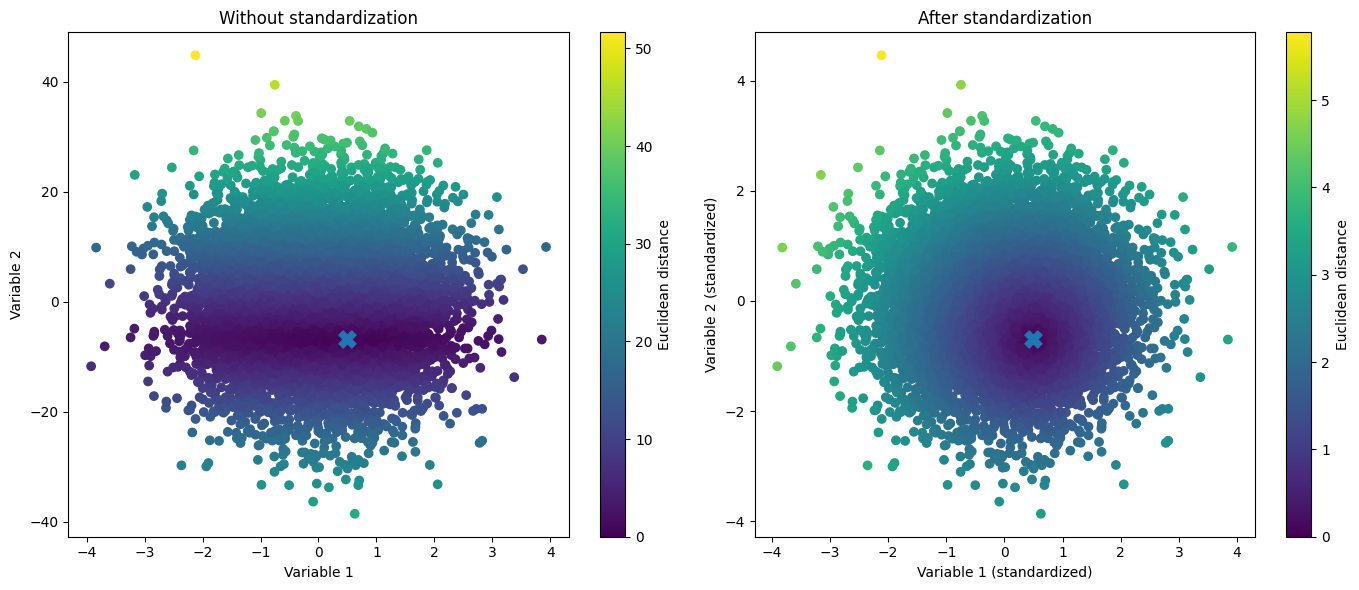

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------
# Original data
# --------------------------------------------------

scatter = axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=distances,
    cmap="viridis"
)

axes[0].scatter(
    X[0, 0],
    X[0, 1],
    marker="X",
    s=150
)

axes[0].set_xlabel("Variable 1")
axes[0].set_ylabel("Variable 2")
axes[0].set_title("Without standardization")

fig.colorbar(
    scatter,
    ax=axes[0],
    label="Euclidean distance"
)


# --------------------------------------------------
# Standardized data
# --------------------------------------------------

scatter = axes[1].scatter(
    X_standardized[:, 0],
    X_standardized[:, 1],
    c=distances_standardized,
    cmap="viridis"
)

axes[1].scatter(
    X_standardized[0, 0],
    X_standardized[0, 1],
    marker="X",
    s=150
)

axes[1].set_xlabel("Variable 1 (standardized)")
axes[1].set_ylabel("Variable 2 (standardized)")
axes[1].set_title("After standardization")

fig.colorbar(
    scatter,
    ax=axes[1],
    label="Euclidean distance"
)

plt.tight_layout()
plt.show()

## 02 What is exactly a group?

Now we are going to create new synthetic data, but instead of sampling from one distribution, we are going to join data from 3 different distributions

In [33]:
np.random.seed(42)

X1 = np.random.normal(loc=[0, 0], scale=0.7, size=(50, 2))
X2 = np.random.normal(loc=[4, 4], scale=0.7, size=(50, 2))
X3 = np.random.normal(loc=[0, 5], scale=0.7, size=(50, 2))

X = np.vstack([X1, X2, X3])

Visually, these groups are well-separated, and we can see that the distances between points in different groups are larger than the distances between points within the same group. This is a key concept in clustering, where we aim to group similar data points together based on their features. Data from the same group should be close together, and data from different groups should be far appart

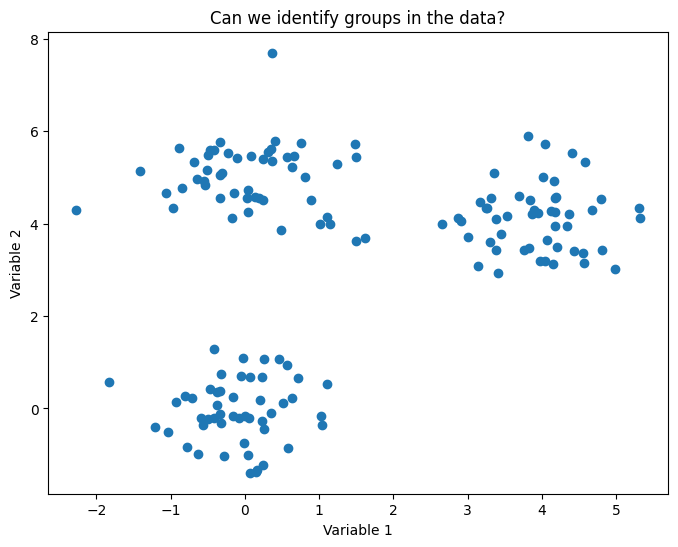

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Can we identify groups in the data?")

plt.show()

Usually our data is not as well separated as in the previous example. Let's see how we can identify groups in a more complex dataset.

In [35]:
np.random.seed(42)

X1 = np.random.normal(loc=[0, 0], scale=0.7, size=(50, 2))
X2 = np.random.normal(loc=[4, 4], scale=0.7, size=(50, 2))
X3 = np.random.normal(loc=[2, 4], scale=0.7, size=(50, 2))

X = np.vstack([X1, X2, X3])

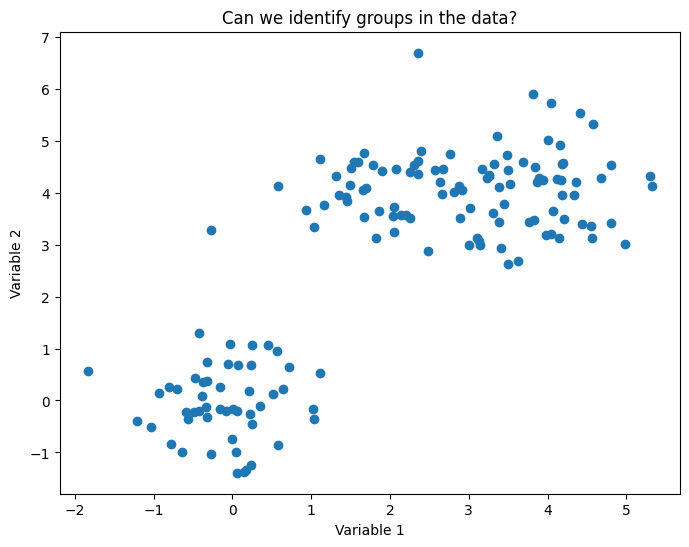

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Can we identify groups in the data?")

plt.show()

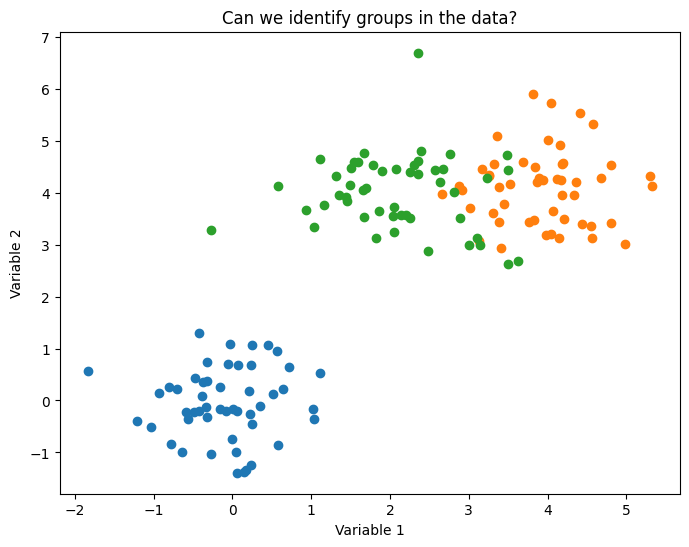

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(X1[:, 0], X1[:, 1])
plt.scatter(X2[:, 0], X2[:, 1])
plt.scatter(X3[:, 0], X3[:, 1])

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Can we identify groups in the data?")

plt.show()

The appropriate number of clusters (K) depends on the application and the purpose of the clustering. In some cases, the data may come from a small number of clearly separated populations, and we may therefore want to identify only a few distinct clusters. In other cases, the data may form a more continuous and mixed distribution, with no obvious natural groups. We may still choose a value of K to divide the data into a convenient number of groups for exploration, interpretation, or subsequent modelling. Therefore, there is not necessarily one "correct" number of clusters—the appropriate choice depends on what we want the clustering to achieve.

We are going to use K-means, in which the number of clusters \(K\) must be provided by the user before applying the algorithm. Other clustering algorithms can determine the number of clusters based on different criteria, although they generally still require parameters or assumptions that influence the resulting groups.

An additional concept that is useful for understanding clustering is the idea of a **centroid**. Once we have a cluster of observations, we can compute its centroid, which can be thought of as the **centre of the cluster**.

The centroid is obtained by calculating the mean of each variable across all the observations in the cluster. It therefore represents the **average characteristics** of the observations belonging to that cluster.

In many applications, the centroid can be used as a representative of the cluster. Instead of considering every individual observation separately, we can use the centroid to describe the typical properties of the group.

For a cluster $C$ containing $n_C$ observations and $p$ variables, the centroid is calculated as:

$$
\boldsymbol{\mu}_C =
\frac{1}{n_C}
\sum_{i \in C} \mathbf{x}_i
$$

where $\boldsymbol{\mu}_C$  is the centroid of the cluster and $x_i$ is the vector of variables corresponding to observation $i$.


In [38]:
centroid_1 = X1.mean(axis=0)
centroid_2 = X2.mean(axis=0)
centroid_3 = X3.mean(axis=0)

print("Centroid 1:", centroid_1)
print("Centroid 2:", centroid_2)
print("Centroid 3:", centroid_3)

Centroid 1: [-0.09497294 -0.05041218]
Centroid 2: [3.93318298 4.09804344]
Centroid 3: [2.09026273 4.00059203]


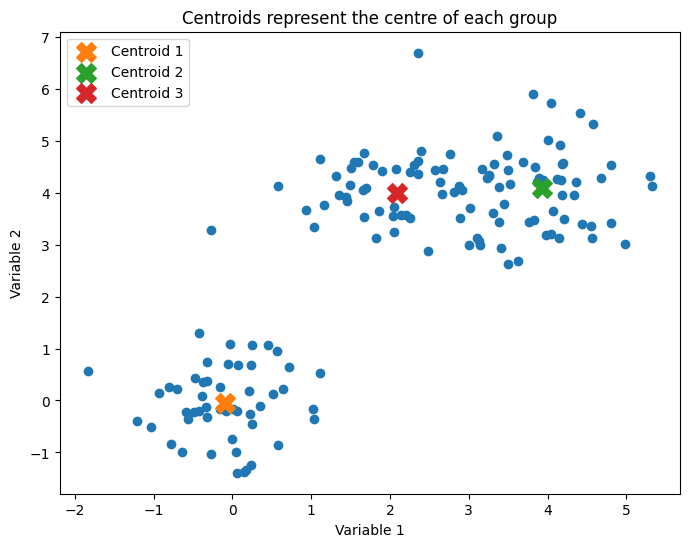

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1])

plt.scatter(
    centroid_1[0], centroid_1[1],
    marker="X", s=200, label="Centroid 1"
)

plt.scatter(
    centroid_2[0], centroid_2[1],
    marker="X", s=200, label="Centroid 2"
)

plt.scatter(
    centroid_3[0], centroid_3[1],
    marker="X", s=200, label="Centroid 3"
)

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Centroids represent the centre of each group")
plt.legend()

plt.show()

The quality of a cluster can therefore be evaluated based on how compact it is. Ideally, the observations within a cluster should be close to one another and, consequently, close to their centroid.

In [40]:
centroid = X1.mean(axis=0)

distances = np.sqrt(
    (X1[:, 0] - centroid[0])**2 +
    (X1[:, 1] - centroid[1])**2
)

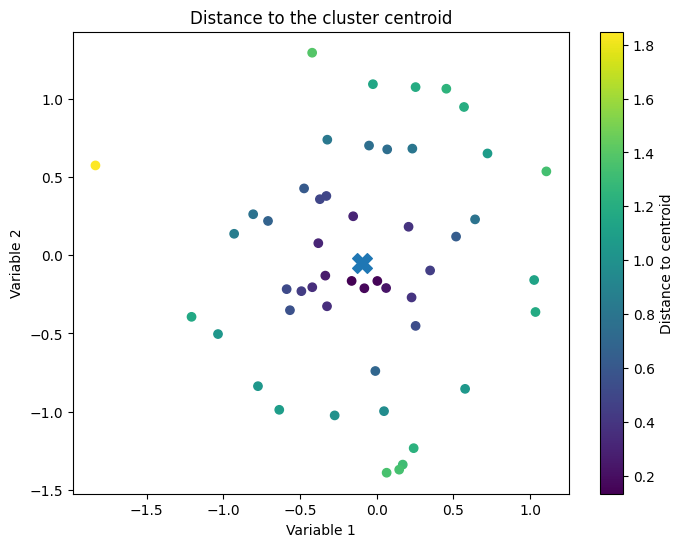

In [41]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X1[:, 0],
    X1[:, 1],
    c=distances,
    cmap="viridis"
)

plt.scatter(
    centroid[0],
    centroid[1],
    marker="X",
    s=200
)

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Distance to the cluster centroid")

plt.colorbar(scatter, label="Distance to centroid")

plt.show()

How can we automatically divide our observations into \(K\) clusters such that the clusters are as compact as possible?

## 03 K-Means algorithm

The K-Means algorithm is one of the most commonly used clustering algorithms. Although several variants exist, in this notebook we will focus on the standard K-Means algorithm.

K-Means is an iterative algorithm: it repeatedly performs a sequence of steps, updating the cluster assignments and centroids until the solution converges. Note that the number of clusters must be specified by the user before applying the K-Means algorithm.

K-Means Steps

1. Initialize the centroids. We select (K) initial centroids. For now, we will choose them randomly. Other initialization methods can be used to improve the starting point and are implemented in the libraries we will use later.
2. Assign observations to clusters. Each observation is assigned to the cluster whose centroid is closest according to the chosen dissimilarity measure.
3. Update the centroids. We recalculate each centroid as the mean of the observations currently assigned to that cluster. The initial centroids were only starting points and do not necessarily represent the centre of their final clusters.
4. Steps 2 and 3 are then repeated iteratively until convergence, that is, until the cluster assignments or centroids no longer change significantly.

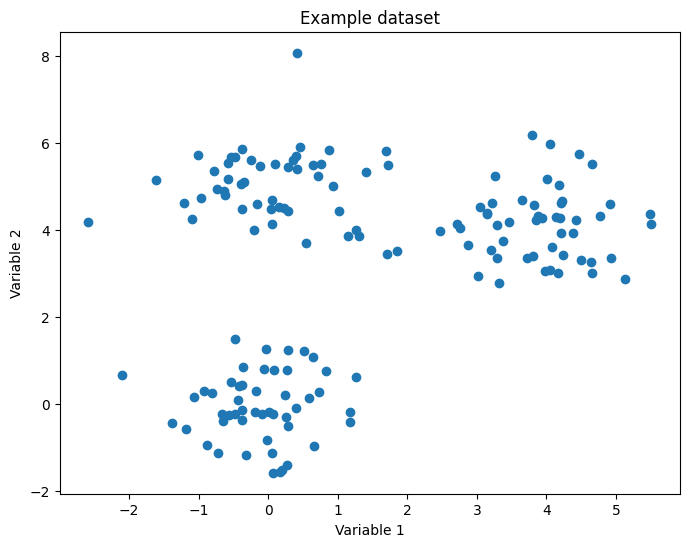

In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate three groups
X1 = np.random.normal(loc=[0, 0], scale=0.8, size=(50, 2))
X2 = np.random.normal(loc=[4, 4], scale=0.8, size=(50, 2))
X3 = np.random.normal(loc=[0, 5], scale=0.8, size=(50, 2))

# Combine into a single dataset
X = np.vstack([X1, X2, X3])

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Example dataset")

plt.show()

#### Step 1: Lets select random centroids

In [43]:
# Choose 3 random observations as initial centroids
indices = np.random.choice(len(X), size=3, replace=False)

centroids = X[indices]

print(centroids)

[[-0.0576081   0.80282632]
 [-0.36851102  0.84569778]
 [ 2.86770341  3.66348374]]


Therefore this is our initial guess

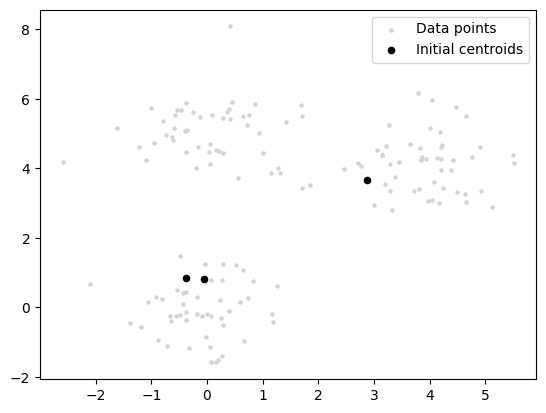

In [44]:
plt.scatter(X[:, 0], X[:, 1], s=5,label="Data points", color='lightgray')
plt.scatter(centroids[:, 0], centroids[:, 1], s=20, label="Initial centroids", color='k')
plt.legend()

#### Step 2: Lets assing each of the points a cluster to the nearest centroid

In [45]:
data = pd.DataFrame(X)
data.columns = ['Variable 1', 'Variable 2']
print(data)

for i, centroid in enumerate(centroids):
    
    distance_to_centroid = np.sqrt(
        (X[:, 0] - centroid[0])**2 +
        (X[:, 1] - centroid[1])**2
    )

    data[f'Distance_to_centroid_{i}'] = distance_to_centroid

data['assigned_cluster'] = (
    data[
        [f'Distance_to_centroid_{i}' for i in range(len(centroids))]
    ]
    .idxmin(axis=1)
    .str.replace('Distance_to_centroid_', 'cluster_')
)

     Variable 1  Variable 2
0      0.397371   -0.110611
1      0.518151    1.218424
2     -0.187323   -0.187310
3      1.263370    0.613948
4     -0.375580    0.434048
..          ...         ...
145   -0.166498    4.605599
146   -0.471492    5.679682
147    0.285612    4.445672
148    0.719680    5.245840
149    0.650290    5.503703

[150 rows x 2 columns]


#### Step 3: Lets calculate the new clusters and new centroids

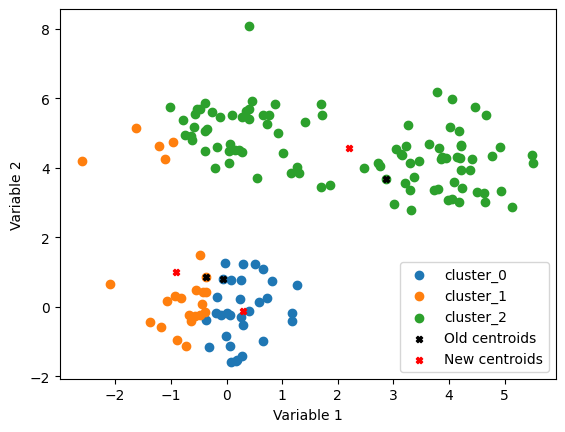

In [46]:
fig, ax = plt.subplots()
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")

for cluster in ['cluster_0', 'cluster_1', 'cluster_2']:
    
    cluster_data = data[data['assigned_cluster'] == cluster]

    ax.scatter(
        cluster_data['Variable 1'],
        cluster_data['Variable 2'],
        label=cluster
    )

ax.scatter(centroids[:, 0], centroids[:, 1], s=20, label="Old centroids", color='k', marker="X")
new_centroids = np.array([
    data[data['assigned_cluster'] == f'cluster_{i}'][['Variable 1', 'Variable 2']].mean().values
    for i in range(len(centroids))
])
ax.scatter(new_centroids[:, 0], new_centroids[:, 1], s=20, label="New centroids", color='r', marker="X")

ax.legend()
plt.show()

#### Step 4: Iterate

In [47]:
data = pd.DataFrame(X)
data.columns = ['Variable 1', 'Variable 2']
print(data)

for i, centroid in enumerate(new_centroids):
    
    distance_to_centroid = np.sqrt(
        (X[:, 0] - centroid[0])**2 +
        (X[:, 1] - centroid[1])**2
    )

    data[f'Distance_to_centroid_{i}'] = distance_to_centroid

data['assigned_cluster'] = (
    data[
        [f'Distance_to_centroid_{i}' for i in range(len(new_centroids))]
    ]
    .idxmin(axis=1)
    .str.replace('Distance_to_centroid_', 'cluster_')
)

     Variable 1  Variable 2
0      0.397371   -0.110611
1      0.518151    1.218424
2     -0.187323   -0.187310
3      1.263370    0.613948
4     -0.375580    0.434048
..          ...         ...
145   -0.166498    4.605599
146   -0.471492    5.679682
147    0.285612    4.445672
148    0.719680    5.245840
149    0.650290    5.503703

[150 rows x 2 columns]


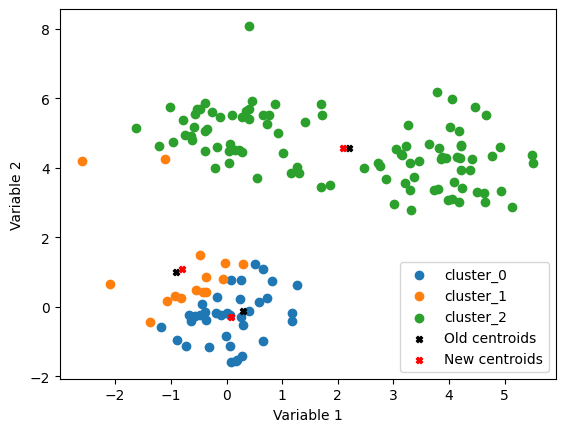

In [48]:
fig, ax = plt.subplots()
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")

for cluster in ['cluster_0', 'cluster_1', 'cluster_2']:
    
    cluster_data = data[data['assigned_cluster'] == cluster]

    ax.scatter(
        cluster_data['Variable 1'],
        cluster_data['Variable 2'],
        label=cluster
    )

ax.scatter(new_centroids[:, 0], new_centroids[:, 1], s=20, label="Old centroids", color='k', marker="X")
new_centroids_2 = np.array([
    data[data['assigned_cluster'] == f'cluster_{i}'][['Variable 1', 'Variable 2']].mean().values
    for i in range(len(centroids))
])
ax.scatter(new_centroids_2[:, 0], new_centroids_2[:, 1], s=20, label="New centroids", color='r', marker="X")

ax.legend()
plt.show()

Lets build a loop

In [52]:
n_iter = 10
rng = np.random.default_rng(42)
# Initial centroids
centroids = X[np.random.choice(len(X), size=3, replace=False)]

history = []

for iteration in range(n_iter):

    # -------------------------
    # 1. Assign observations
    # -------------------------
    distances = np.zeros((len(X), len(centroids)))

    for i, centroid in enumerate(centroids):
        distances[:, i] = np.sqrt(
            (X[:, 0] - centroid[0])**2 +
            (X[:, 1] - centroid[1])**2
        )

    labels = np.argmin(distances, axis=1)

    # -------------------------
    # 2. Update centroids
    # -------------------------
    new_centroids = np.array([
        X[labels == i].mean(axis=0)
        for i in range(len(centroids))
    ])

    # Save this iteration
    history.append({
        "iteration": iteration,
        "labels": labels.copy(),
        "centroids": centroids.copy(),
        "new_centroids": new_centroids.copy()
    })

    # Update centroids
    centroids = new_centroids

In [53]:
history

[{'iteration': 0,
  'labels': array([1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1,
         1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2,
         2, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
         2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  'centroids': array([[ 3.0469572 ,  4.52524289],
         [ 0.28930882, -0.5160958 ],
         [ 0.07766204,  0.77491599]]),
  'new_centroids': array([[ 2.19023757,  4.56255298],
         [-0.08952339, -0.61636323],
         [-0.35752534,  1.35449088]])},
 {'iteration': 1,
  'labels': array([1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1,
         1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1,
         2, 2, 1, 1, 1

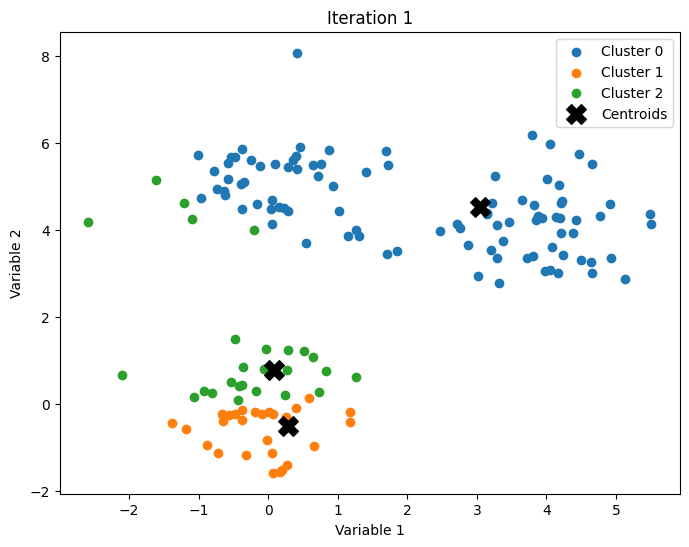

In [54]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):

    ax.clear()

    labels = history[frame]["labels"]
    centroids = history[frame]["centroids"]

    for i in range(len(centroids)):

        cluster_data = X[labels == i]

        ax.scatter(
            cluster_data[:, 0],
            cluster_data[:, 1],
            label=f"Cluster {i}"
        )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="X",
        s=200,
        color="black",
        label="Centroids"
    )

    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.set_title(f"Iteration {frame + 1}")
    ax.legend()


animation = FuncAnimation(
    fig,
    update,
    frames=len(history),
    interval=1000,
    repeat=False
)

HTML(animation.to_jshtml())


The choice of the initial centroids can have an important effect on the behaviour of the K-Means algorithm.

With **seed 42**, two of the initial centroids are placed within the southern group. As a result, both centroids compete for observations in this region, while no centroid is initially located in the other region. The centroids therefore have to move progressively towards their final positions through the iterative reassignment and update process.

With **seed 10**, the initial centroids happen to be much closer to the centres of the three underlying distributions. Consequently, the observations are assigned to well-defined groups almost immediately, and the centroids converge quickly to their final positions.

This illustrates an important characteristic of K-Means: **the final clustering can depend on the initialisation of the centroids**.


## 04 BlueMath

BlueMath has its own implementation of clustering algorithms, including K-Means. You can use the `BlueMath` library to perform K-Means clustering on your dataset. Here's an example of how to use it:

In [55]:
from bluemath_tk.datamining import KMA

In [56]:
kma_ob = KMA(num_clusters=3)

In [57]:
kma_bmus, _  = kma_ob.fit_predict(pd.DataFrame(X))

(<Figure size 640x480 with 1 Axes>,
 array([[<Axes: xlabel='1', ylabel='0'>]], dtype=object))

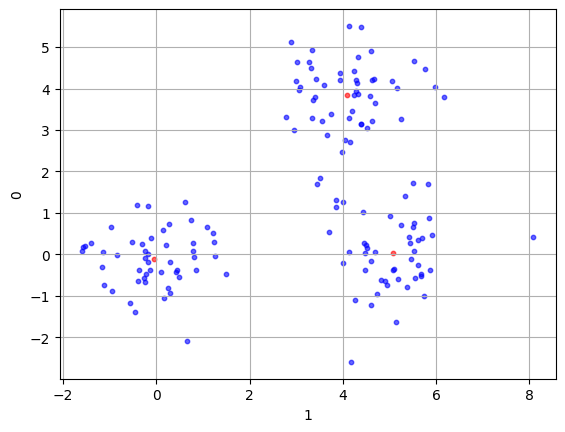

In [59]:
kma_ob.plot_selected_centroids()

#### BlueMath Arguments

In [61]:
'''
    Parameters
    ----------
    data : pd.DataFrame
        The input data to be used for the KMA algorithm.
    directional_variables : List[str], optional
        A list of directional variables that will be transformed to u and v components.
        Then, to use custom_scale_factor, you must specify the variables names with the u and v suffixes.
        Example: directional_variables=["Dir"], custom_scale_factor={"Dir_u": [0, 1], "Dir_v": [0, 1]}.
        Default is [].
    custom_scale_factor : dict, optional
        A dictionary specifying custom scale factors for normalization.
        If normalize_data is True, this will be used to normalize the data.
        Example: {"Hs": [0, 10], "Tp": [0, 10]}.
        Default is {}.
    min_number_of_points : int, optional
        The minimum number of points to consider a cluster.
        Default is None.
    max_number_of_iterations : int, optional
        The maximum number of iterations for the K-Means algorithm.
        This is used when min_number_of_points is not None.
        Default is 10.
    normalize_data : bool, optional
        A flag to normalize the data.
        If True, the data will be normalized using the custom_scale_factor.
        Default is False.
    regression_guided: dict, optional
        A dictionary specifying regression-guided clustering variables and relative weights.
        Example: {"vars": ["Fe"], "alpha": [0.6]}.
        Default is {}.
'''

'\n    Parameters\n    ----------\n    data : pd.DataFrame\n        The input data to be used for the KMA algorithm.\n    directional_variables : List[str], optional\n        A list of directional variables that will be transformed to u and v components.\n        Then, to use custom_scale_factor, you must specify the variables names with the u and v suffixes.\n        Example: directional_variables=["Dir"], custom_scale_factor={"Dir_u": [0, 1], "Dir_v": [0, 1]}.\n        Default is [].\n    custom_scale_factor : dict, optional\n        A dictionary specifying custom scale factors for normalization.\n        If normalize_data is True, this will be used to normalize the data.\n        Example: {"Hs": [0, 10], "Tp": [0, 10]}.\n        Default is {}.\n    min_number_of_points : int, optional\n        The minimum number of points to consider a cluster.\n        Default is None.\n    max_number_of_iterations : int, optional\n        The maximum number of iterations for the K-Means algorithm.

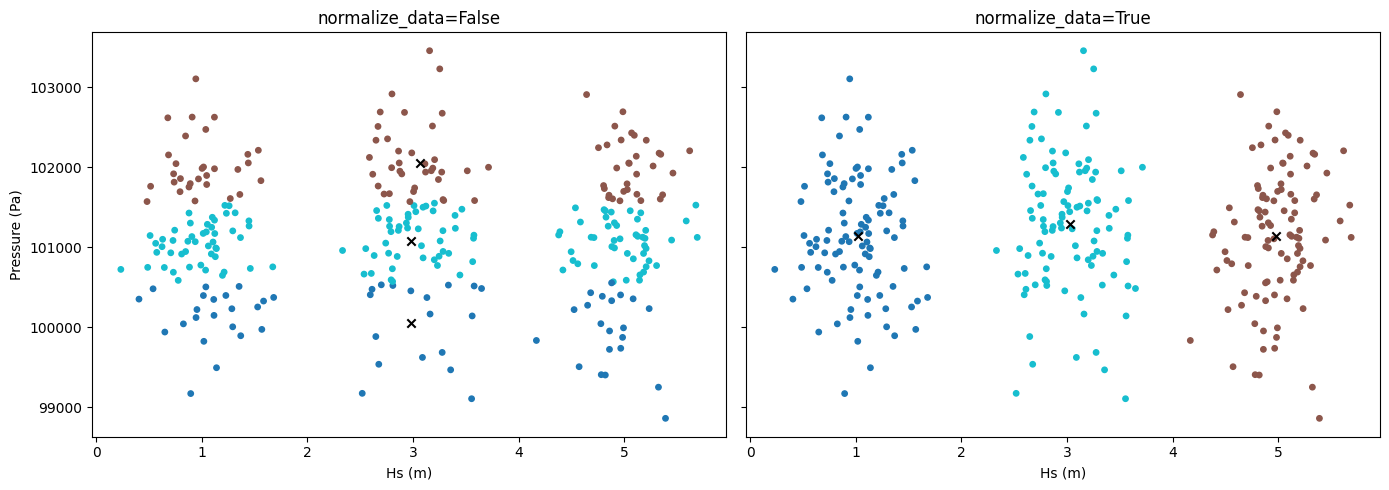

In [74]:
np.random.seed(0)
n = 100

hs = np.concatenate([
    np.random.normal(1, 0.3, n),
    np.random.normal(3, 0.3, n),
    np.random.normal(5, 0.3, n),
])
pressure = np.random.normal(101300, 800, 3 * n)   # noise, but huge units

df_norm = pd.DataFrame({"Hs": hs, "Pressure": pressure})

kma_ob = KMA(num_clusters=3)

bmus_raw, _ = kma_ob.fit_predict(df_norm, normalize_data=False)
cents_raw = kma_ob.centroids
bmus_nrm, _ = kma_ob.fit_predict(df_norm, normalize_data=True)
cents_nrm = kma_ob.centroids

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, bmus, title, cents in zip(axes,
                           [bmus_raw['kma_bmus'].values, bmus_nrm['kma_bmus'].values],
                           ["normalize_data=False", "normalize_data=True"],
                           [cents_raw,cents_nrm]):
    ax.scatter(df_norm["Hs"], df_norm["Pressure"], c=bmus, cmap="tab10", s=15)
    ax.scatter(cents['Hs'], cents['Pressure'], color = 'k', marker='x')
    ax.set_xlabel("Hs (m)")
    ax.set_title(title)
axes[0].set_ylabel("Pressure (Pa)")
plt.tight_layout()
plt.show()

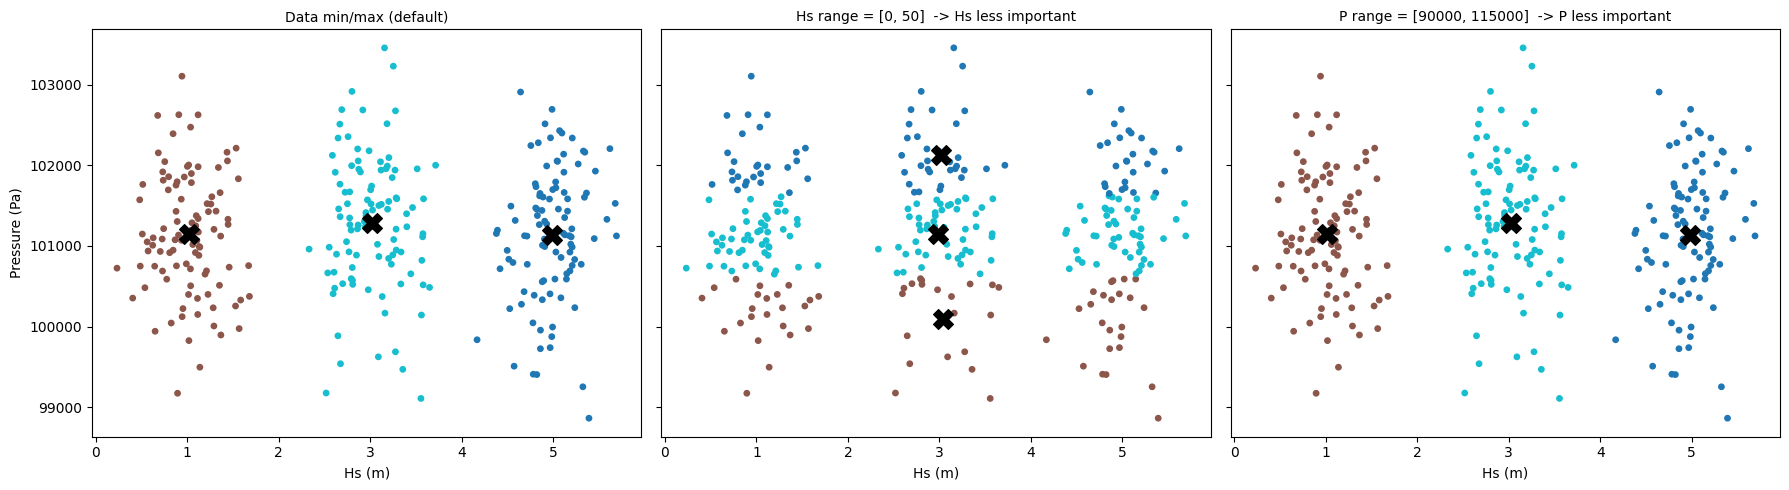

In [75]:
default_sf = {
    "Hs": [df_norm["Hs"].min(), df_norm["Hs"].max()],
    "Pressure": [df_norm["Pressure"].min(), df_norm["Pressure"].max()],
}

downweight_hs = {
    "Hs": [0, 50],   # Hs now only spans ~0-0.1 after scaling
    "Pressure": default_sf["Pressure"],
}

downweight_p = {
    "Hs": default_sf["Hs"],
    "Pressure": [90000, 115000],   # Pressure now only spans ~0-0.2
}

cases = {
    "Data min/max (default)": default_sf,
    "Hs range = [0, 50]  -> Hs less important": downweight_hs,
    "P range = [90000, 115000]  -> P less important": downweight_p,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (title, sf) in zip(axes, cases.items()):
    bmus, _ = kma_ob.fit_predict(df_norm, normalize_data=True, custom_scale_factor=sf)
    bmus = bmus['kma_bmus'].values
    ax.scatter(df_norm["Hs"], df_norm["Pressure"], c=bmus, cmap="tab10", s=15)
    cents = kma_ob.centroids
    ax.scatter(cents["Hs"], cents["Pressure"], marker="X", s=200, c="k")
    ax.set_xlabel("Hs (m)")
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel("Pressure (Pa)")
plt.tight_layout()
plt.show()

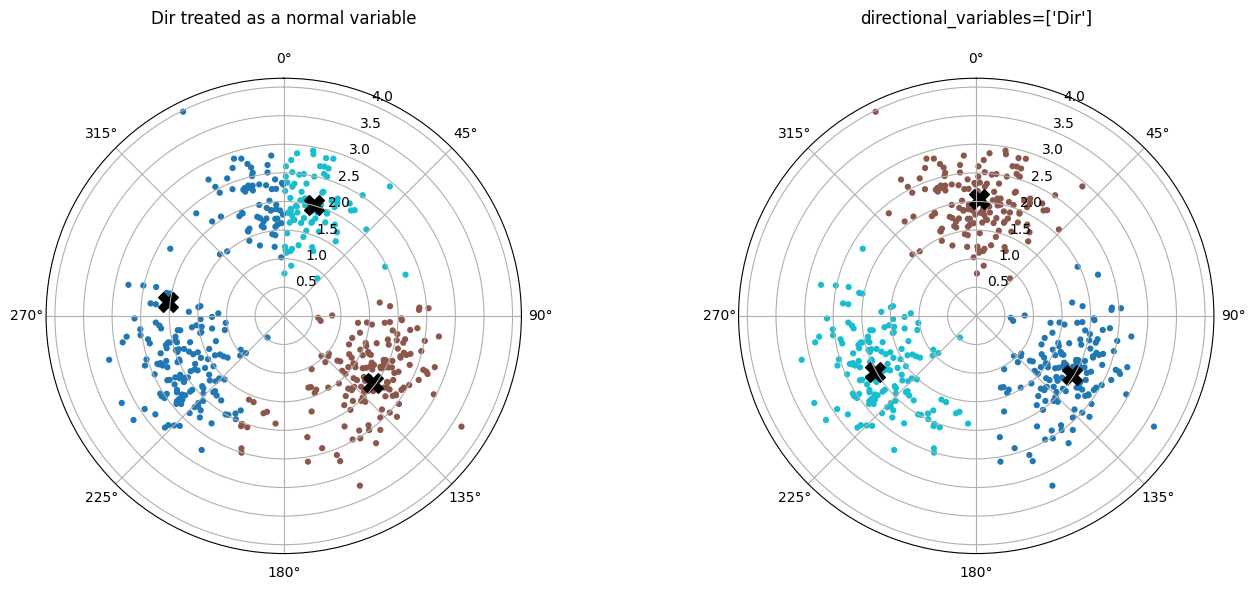

In [76]:
np.random.seed(1)
n = 150

direction = np.concatenate([
    np.random.normal(0, 20, n),     # around North (wraps around 360)
    np.random.normal(120, 20, n),
    np.random.normal(240, 20, n),
]) % 360
hs = np.random.normal(2, 0.5, 3 * n)

df_dir = pd.DataFrame({"Hs": hs, "Dir": direction})

bmus_lin  , _ = kma_ob.fit_predict(df_dir,  normalize_data=True)
bmus_lin = bmus_lin['kma_bmus'].values
cents_lin = kma_ob.centroids
bmus_circ , _ = kma_ob.fit_predict(df_dir,  normalize_data=True, directional_variables=["Dir"])
bmus_circ = bmus_circ['kma_bmus'].values
cents_circ = kma_ob.centroids


fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "polar"})
for ax, bmus, dir_cols, title, cents in zip(
        axes,
        [bmus_lin, bmus_circ],
        [(), ("Dir",)],
        ["Dir treated as a normal variable", "directional_variables=['Dir']"],
        [cents_lin, cents_circ]):

    ax.set_theta_zero_location("N")   # 0 deg at the top
    ax.set_theta_direction(-1)        # clockwise, like a compass
    ax.scatter(np.deg2rad(df_dir["Dir"]), df_dir["Hs"], c=bmus, cmap="tab10", s=12)
    ax.scatter(np.deg2rad(cents["Dir"]), cents["Hs"], marker="X", s=200, c="k")
    ax.set_title(title, pad=20)

plt.tight_layout()
plt.show()

No constraint: smallest cluster has 40 points
min_number_of_points=1: smallest cluster has 2 points


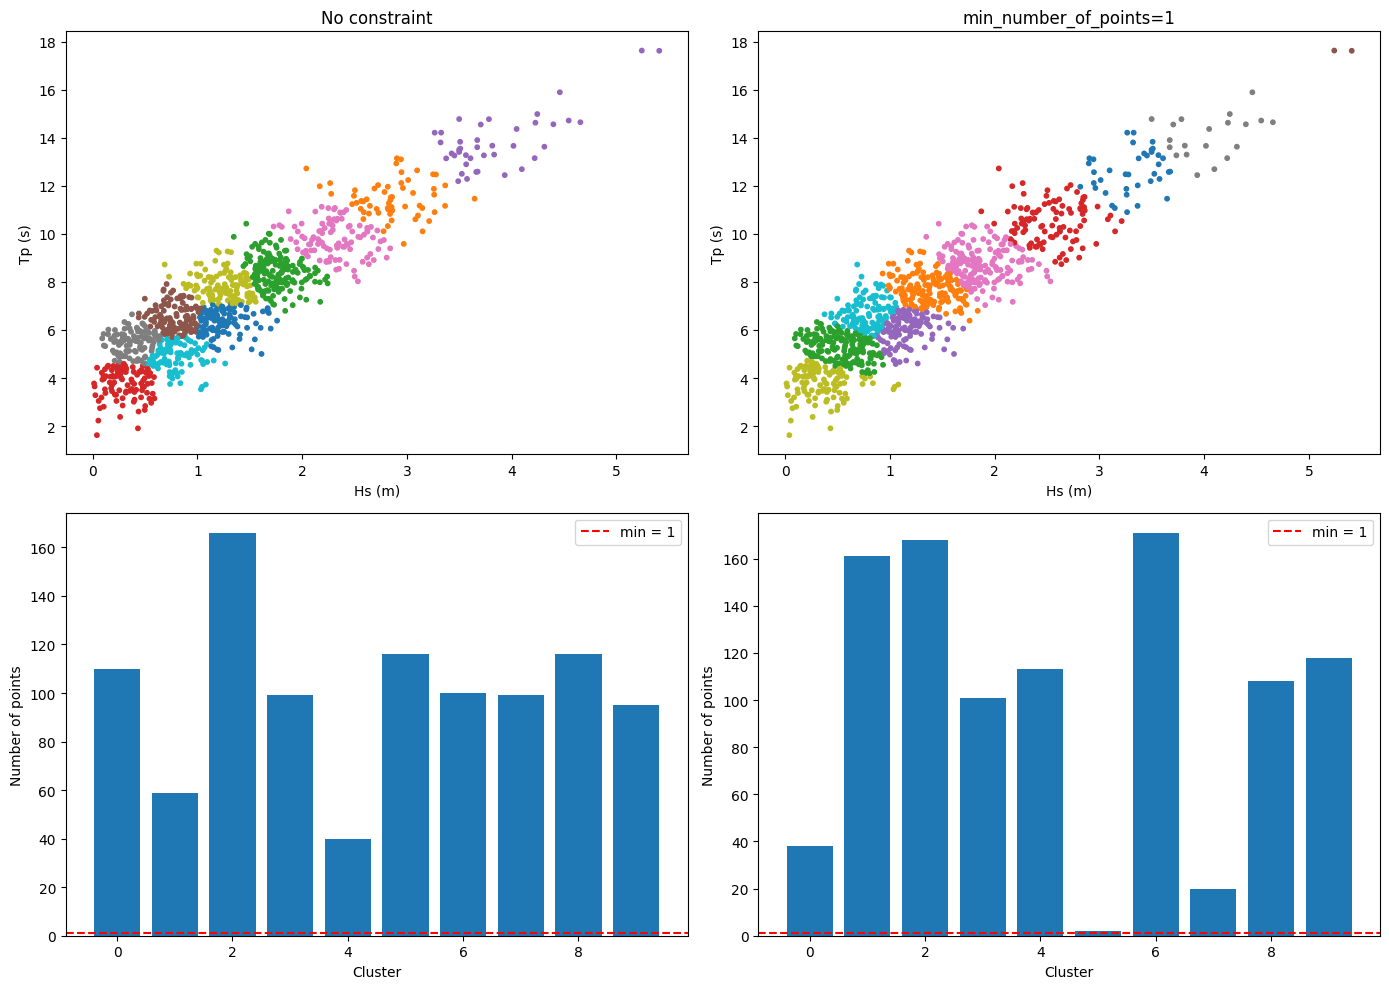

In [86]:
np.random.seed(3)
n = 1000

hs = np.random.weibull(1.5, n) * 1.5                 # skewed, long tail like real Hs
tp = 4 + 2.5 * hs + np.random.normal(0, 1, n)         # Tp correlated with Hs
df_mp = pd.DataFrame({"Hs": hs, "Tp": tp})

k = 10
min_pts = 1

kma_ob = KMA(num_clusters=k)
bmus_free , _= kma_ob.fit_predict(df_mp, normalize_data=True)
bmus_free = bmus_free['kma_bmus'].values
try:
    bmus_min, _ = kma_ob.fit_predict(df_mp, normalize_data=True,
                          min_number_of_points=min_pts,
                          max_number_of_iterations=100)
    bmus_min = bmus_min['kma_bmus'].values

except Exception as e:
    print("Could not satisfy the constraint:", e)
    bmus_min = None

results = {"No constraint": bmus_free}
if bmus_min is not None:
    results[f"min_number_of_points={min_pts}"] = bmus_min

fig, axes = plt.subplots(2, len(results), figsize=(7 * len(results), 10), squeeze=False)
for j, (title, bmus) in enumerate(results.items()):
    axes[0, j].scatter(df_mp["Hs"], df_mp["Tp"], c=bmus, cmap="tab10", s=10)
    axes[0, j].set_xlabel("Hs (m)")
    axes[0, j].set_ylabel("Tp (s)")
    axes[0, j].set_title(title)

    sizes = np.bincount(bmus, minlength=k)
    axes[1, j].bar(range(k), sizes)
    axes[1, j].axhline(min_pts, color="r", ls="--", label=f"min = {min_pts}")
    axes[1, j].set_xlabel("Cluster")
    axes[1, j].set_ylabel("Number of points")
    axes[1, j].legend()
    print(f"{title}: smallest cluster has {sizes.min()} points")

plt.tight_layout()
plt.show()